In [1]:
###########################################################################
##### CODE FOR PROJECT: "sp500-prediction-interval-analysis"
###########################################################################

In [2]:
# import libaries
import yfinance as yf, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm, numpy as np

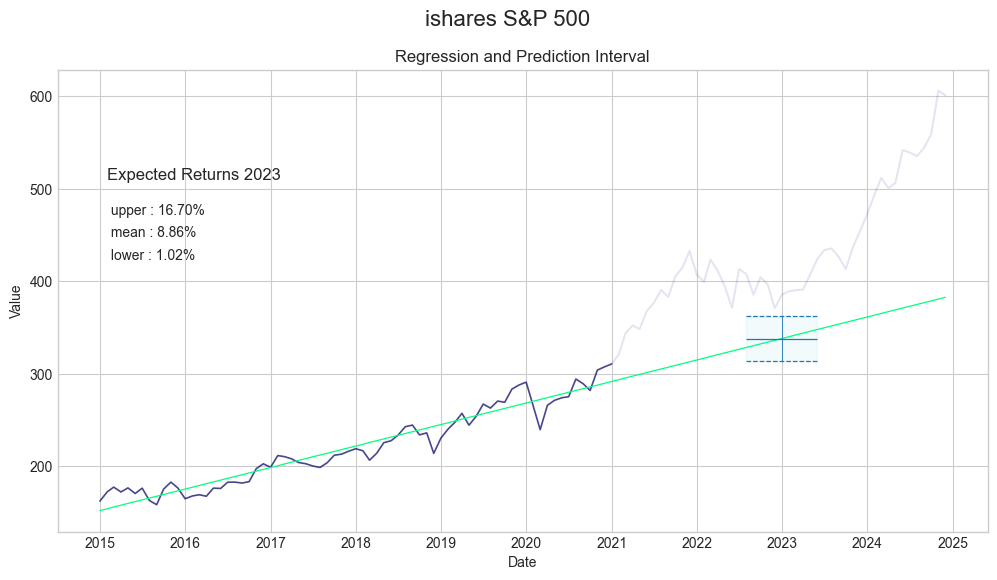

In [4]:
# load data
sp500 = yf.download("SXR8.DE", start="2015-01-01", end="2025-01-01",interval="1mo", progress=False, auto_adjust=True)

# set figure and theme
plt.figure(figsize = (12,6))
plt.style.use("seaborn-v0_8-whitegrid")

# get year indexes from dataframe
n = sp500["Close"].index.get_loc("2021-01-01")
nt = sp500["Close"].index.get_loc("2023-01-01")

# plot charts
plt.plot(sp500["Close"][:n+1], color="midnightblue", lw=1.2, alpha=0.8)
plt.plot(sp500["Close"][n:], color="navy", alpha=0.1)

# define variables for regression and prediction
y = sp500["Close"]["SXR8.DE"].values 
yn = sp500["Close"]["SXR8.DE"][0:n+1].values 
x = np.arange(len(y)) 
xn = np.arange(len(yn))

# use statsmodels zu create model
x1 = sm.add_constant(xn)
x2 = sm.add_constant(x)
model = sm.OLS(yn,x1).fit()

# predictions model
y_pred = model.predict(x2)
pred_df = model.get_prediction(x2).summary_frame()

# get specific predictions
KI_lo = pred_df.loc[nt,"obs_ci_lower"]
KI_up = pred_df.loc[nt,"obs_ci_upper"]

# plot regression line
plt.plot(sp500["Close"].index, y_pred , color = "springgreen", lw=0.9)

# timeframe for grafics 
ix1 = sp500["Close"].index[nt-5]
ix2 = sp500["Close"].index[nt+5]

# draw prediction interval lines
plt.hlines(KI_lo,ix1,ix2,lw=0.9, linestyle="dashed")
plt.hlines(KI_up,ix1,ix2,lw=0.9, linestyle="dashed")

# mean line
plt.hlines(y_pred[nt],ix1,ix2,lw=0.9)

# 2023 timeline 
plt.vlines(x = sp500["Close"].index[nt],lw=0.6, ymin=KI_lo, ymax=KI_up)

# graphic area filling
plt.fill_between([ix1,ix2],KI_up,KI_lo,alpha=0.1, color="skyblue")

# calculate return
outcomes = [KI_lo,y_pred[nt], KI_up]
base = sp500["Close"]["SXR8.DE"].iloc[n]

re_lower = outcomes[0]/(base)-1
re_mean = outcomes[1]/(base)-1
re_upper = outcomes[2]/(base)-1

labels = [
    ("lower ", re_lower, outcomes[0]),
    ("mean ", re_mean, outcomes[1]),
    ("upper ", re_upper, outcomes[2])]

# annotate title for return
plt.annotate("Expected Returns 2023",xy=(sp500["Close"].index[1],510), fontsize=12)

# annotate return 
for label, ret, val in labels:
    plt.annotate(
        f" {label}: {ret:.2%}",
        xy=(sp500["Close"].index[1], val+110),
        xytext=(0,0),
        textcoords="offset points",
        fontsize=10
    )

# labels 
plt.title("Regression and Prediction Interval",size=12)
plt.suptitle("ishares S&P 500", size=16)
plt.xlabel("Date")
plt.ylabel("Value")

# save plot
plt.savefig(
    "prediction_interval.png",
    dpi=300,
    bbox_inches="tight"
)

    
plt.show()